[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanNece/LABS_ML_Vision_Multimedia/blob/main/Lab02_HyperparameterSelection/Hyper-parameter%20tuning%20on%20Fashion-MNIST%20(PyTorch).ipynb)

# Hyper-parameter tuning on Fashion-MNIST (PyTorch)

## Step 1 - Preparing the notebook

Goal: prepare the notebook with the core libraries and confirm that GPU is enabled in Colab.

Checklist:
- Runtime set to GPU (Runtime → Change runtime type → Hardware accelerator: GPU)
- Core libraries imported (torch, torchvision, matplotlib, numpy)
- Device printed (expect: cuda)

In [2]:
# Core libs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Vision datasets and transforms
import torchvision
from torchvision import datasets, transforms

# Utils
import numpy as np
import random
import time
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


PyTorch: 2.8.0+cu126
Torchvision: 0.23.0+cu126


In [3]:
# Select device (expect CUDA on Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# If GPU is available, print GPU name for confirmation
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA available:", torch.cuda.is_available())
else:
    # Gentle reminder if GPU is not active
    print("Warning: GPU is not active. In Colab, go to Runtime → Change runtime type → GPU.")


Device: cuda
GPU: Tesla T4
CUDA available: True


## Step 2 — Data: train/val/test split and DataLoaders

### Understanding the Fashion-MNIST dataset

What the dataset is
- Fashion-MNIST is a collection of 70,000 grayscale images of clothing items from 10 categories.
- Each image is 28 by 28 pixels, single channel (grayscale), centered on a black background.
- It is a drop-in replacement for the classic MNIST digits, but with fashion items.
- Split: 60,000 images for training (we further split into train and validation) and 10,000 images for testing.

Classes and label mapping
- There are 10 classes, each mapped to an integer label:
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot
- When you see `Labels range: 0 to 9`, it means labels are integers that index this list of names.
- In code, you often see `class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']`.
  If a sample has `label = 7`, the human-readable class is `class_names[7] = 'Sneaker'`.

Image shape and batch shape
- A single image shape is `[1, 28, 28]`:
  - `1` is the number of channels (grayscale).
  - `28, 28` are height and width in pixels.
- A batch of images shape is `[B, 1, 28, 28]`:
  - `B` is the batch size (for example `64`), the number of images processed together.
  - So `Batch images shape: torch.Size([64, 1, 28, 28])` means 64 grayscale images of size 28x28.
- The labels for that batch have shape `[B]`:
  - `Batch labels shape: torch.Size([64])` means 64 integers, one class label per image.

Pixel values and transforms
- Raw pixels are 0 to 255 (unsigned 8-bit), but we convert them to tensors with values in 0 to 1 using `ToTensor()`.
- We then apply a light normalization, for example `Normalize((0.5,), (0.5,))`, which maps values roughly to the range −1 to +1.
- This normalization makes optimization more stable and comparable across runs.

How we use it in training
- The `DataLoader` groups samples into batches, shuffles the training data each epoch, and leaves validation and test in a fixed order.
- During training, the model sees a batch `[B, 1, 28, 28]`, predicts 10 logits per image, and we compute the loss with the integer labels `[B]`.
- The 10 logits correspond to the 10 classes above. With `CrossEntropyLoss`, we do not apply softmax manually; the loss function handles it internally.

Notes and common confusions
- Some classes look visually similar (for example `Shirt` vs `T-shirt/top` or `Sandal` vs `Sneaker`). This is intentional and makes the task non-trivial.
- All images are the same size and aligned, which keeps the baseline models simple and fast.

Recap
- 10 classes labeled 0 to 9, each mapped to a clothing category.
- Images are grayscale, 28x28, batched as `[B, 1, 28, 28]`.
- Labels are integers `[0..9]`, batched as `[B]`.
- We normalize inputs to improve training stability and monitor overfitting with a validation set.



### Start
Goal:
- Fashion-MNIST provides train (60k) and test (10k). We create a validation set to monitor overfitting.
- We reserve 10 percent of the original training set as validation using `torch.utils.data.random_split`.

Key points:
- Same transforms for train and validation in this lab, because we focus on hyper-parameters (not on heavy augmentation).
- Make the split reproducible by fixing a seed in `torch.Generator`.
- Shuffle only the training loader. Keep validation and test without shuffling.
- Keep batch size fixed at this stage so we can later study the effect of learning rate in isolation.

What you should see:
- Three DataLoaders: train, val, test.
- Batch shapes like: images [64, 1, 28, 28] and labels [64].

Pitfalls:
- Do not shuffle validation or test.
- Keep transforms identical for train and val to isolate hyper-parameter effects.


In [4]:
# Tuning knobs for this step
BATCH_SIZE = 64          # fixed now; we will tune later if needed
VAL_FRACTION = 0.10       # 10 percent of the original training set as validation

# If SEED was not defined in Step 1, define it here (keeps split reproducible)
try:
    SEED
except NameError:
    SEED = 42

# Simple transforms:
# - ToTensor converts [0..255] uint8 to float32 in [0..1]
# - Normalize centers and scales to help optimization
# We keep them identical for train and val to focus on hyper-parameters.
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean 0.5, std 0.5 on the single grayscale channel
])

# Root folder for data. Colab will cache here.
data_root = "./data"

# Load the full training split (60k) and the test split (10k)
train_full = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

# Compute split sizes: 90 percent train, 10 percent val
val_len = int(len(train_full) * VAL_FRACTION)
train_len = len(train_full) - val_len

# Generator with fixed seed for a repeatable split
gen = torch.Generator().manual_seed(SEED)

# Perform the split. Each subset keeps a view over train_full.
from torch.utils.data import random_split, DataLoader
train_dataset, val_dataset = random_split(train_full, [train_len, val_len], generator=gen)

# DataLoader performance flags:
# - pin_memory speeds host to GPU transfers when device is CUDA
# - persistent_workers keeps workers alive across iterations in Colab
pin = (torch.cuda.is_available() and (torch.cuda.device_count() > 0))
num_workers = 2  # 2 is usually safe in Colab without hitting resource limits

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)

# Class names are handy for debug and visualization later
class_names = test_dataset.classes

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")
print("Classes:", class_names)


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.61MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 150kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.4MB/s]

Train size: 54000 | Val size: 6000 | Test size: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Sanity checks
We quickly verify:
- Batch shapes for images and labels.
- Labels are in the expected range 0..9.
- One batch can be moved to GPU without errors.


In [5]:
# Grab one batch from the training loader
xb, yb = next(iter(train_loader))
print("Batch images shape:", xb.shape)  # expect [64, 1, 28, 28]
print("Batch labels shape:", yb.shape)  # expect [64]
print("Labels range:", int(yb.min()), "to", int(yb.max()))  # expect 0..9 inclusive

# Move one batch to the selected device to verify data transfer
try:
    device  # device should be defined in Step 1
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xb = xb.to(device, non_blocking=True)
yb = yb.to(device, non_blocking=True)
print("Moved one batch to:", device)


Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
Labels range: 0 to 9
Moved one batch to: cuda


Recap
- We created a reproducible 90/10 split from the original 60k training set.
- We prepared three DataLoaders with a fixed batch size and identical transforms for train and validation.
- Shapes and label ranges are correct, and a batch moves to GPU. We are ready to define the models.




---


# ⏰***Multilayer Perception (MLP)***

## Step 3 — Model A: MLP baseline (two hidden layers)

Idea
- We flatten each 28x28 image into a 784-length vector and pass it through two Dense (Linear) layers with ReLU.
- The last layer outputs 10 logits (one per class). We do **not** apply Softmax in the model, because CrossEntropyLoss expects raw logits.

Why flattening
- Linear layers work on 1-D inputs. Flatten converts [B, 1, 28, 28] into [B, 784] so the Dense layer can process it.

Shapes (high level)
- Input: 784 features
- Hidden 1: n1 units + ReLU
- Hidden 2: n2 units + ReLU
- Output: 10 logits (mapped to class names by the loss/metrics)

Choosing n1 and n2
- Start with medium sizes, for example (256, 128). They are powerful enough but still fast.
- You can try smaller (128, 64) or larger (512, 256) later to study under/overfitting.

Reading the outputs
- The model returns a tensor [B, 10]. Each row has 10 scores (logits). Higher score → more confident for that class.
- CrossEntropyLoss internally applies log-softmax, so we keep the model simple and return logits directly.

Checks we will do now
- Build the MLP class with Flatten → Linear → ReLU → Linear → ReLU → Linear.
- Run a dummy forward on one batch to confirm output shape [B, 10].
- Print trainable parameter count to compare capacity later with the CNN.


In [6]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """
    Minimal MLP for 28x28 grayscale images:
    - Flatten image to a 1-D vector of length 784
    - Two hidden layers with ReLU activations
    - Output layer with 10 logits (one per Fashion-MNIST class)
    """
    def __init__(self, n1=256, n2=128, num_classes=10):
        super().__init__()
        # Flatten converts [B, 1, 28, 28] -> [B, 784]
        self.flatten = nn.Flatten()

        # First hidden block: Linear + ReLU
        self.fc1 = nn.Linear(28 * 28, n1)
        self.act1 = nn.ReLU(inplace=True)

        # Second hidden block: Linear + ReLU
        self.fc2 = nn.Linear(n1, n2)
        self.act2 = nn.ReLU(inplace=True)

        # Output layer: produce raw logits for 10 classes
        # No Softmax here; CrossEntropyLoss expects raw logits.
        self.fc_out = nn.Linear(n2, num_classes)

    def forward(self, x):
        # x is [B, 1, 28, 28]
        x = self.flatten(x)         # -> [B, 784]
        x = self.act1(self.fc1(x))  # -> [B, n1]
        x = self.act2(self.fc2(x))  # -> [B, n2]
        x = self.fc_out(x)          # -> [B, 10] (logits)
        return x

def count_trainable_params(model: nn.Module) -> int:
    """
    Count the number of trainable parameters.
    This helps reason about model capacity and possible overfitting risk.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Choose default hidden sizes (you can change these later during tuning)
N1, N2 = 256, 128

# Create model and move it to the selected device (from Step 1)
mlp = MLP(n1=N1, n2=N2, num_classes=10).to(device)

# Print parameter count for capacity comparison (vs other MLP sizes or vs CNN later)
print(f"MLP(n1={N1}, n2={N2}) trainable params:", count_trainable_params(mlp))

# Sanity check: run a forward pass on one real batch to confirm the output shape
xb_cpu, yb_cpu = next(iter(train_loader))          # from Step 2
xb_dev = xb_cpu.to(device, non_blocking=True)
with torch.no_grad():
    logits = mlp(xb_dev)                           # expect [BATCH_SIZE, 10]
print("Forward OK. Logits shape:", tuple(logits.shape))


MLP(n1=256, n2=128) trainable params: 235146
Forward OK. Logits shape: (64, 10)


### What to look at
- The parameter count gives an idea of capacity: larger n1 and n2 → more parameters → higher risk of overfitting if not regularized.
- The forward check confirms the model returns 10 logits per image. This is ready for CrossEntropyLoss.



## Step 4 — Training loop, early stopping, and LR scan

Goal
- Train the MLP for up to 30 epochs, or stop early when validation accuracy stops improving.
- Try three learning rates (for example 0.1, 0.01, 0.001) with the **same** batch size.
- For each run, log Train/Val Loss and Train/Val Accuracy and plot both curves.

Why this matters
- Learning rate controls step size in optimization. Too high → divergence or noisy plateaus. Too low → slow learning.
- Early stopping prevents overfitting by keeping the best validation model.

Protocol
- Keep the MLP architecture and the batch size fixed during this LR study.
- For each LR: reinitialize model and optimizer, reset seed for fairness, train with patience-based early stopping, plot curves.


### Utilities: seed, accuracy, plotting

In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch

# Reuse the same seed across runs when we want reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Simple top-1 accuracy in percent
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.numel()
    return 100.0 * correct / total

# Plot function for loss and accuracy, using the collected logs
def plot_learning_curves(log):
    # log keys: "train_loss", "val_loss", "train_acc", "val_acc"
    epochs = range(1, len(log["train_loss"]) + 1)

    # Loss
    plt.figure()
    plt.plot(epochs, log["train_loss"], label="Train Loss")
    plt.plot(epochs, log["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(epochs, log["train_acc"], label="Train Acc")
    plt.plot(epochs, log["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy curves")
    plt.legend()
    plt.show()


### Core loop: one epoch train and evaluate

In [8]:
from torch.nn.functional import cross_entropy

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        # Move batch to device
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # Forward
        logits = model(xb)
        loss = cross_entropy(logits, yb)

        # Backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = cross_entropy(logits, yb)

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


### Train with early stopping and best checkpoint restore

In [9]:
import copy
from typing import Dict

def train_model(
    model_ctor,              # a callable that returns a fresh model instance
    optimizer_ctor,          # a callable that creates an optimizer given model parameters
    train_loader, val_loader,
    device,
    max_epochs: int = 30,
    patience: int = 5,
    seed: int = 42
) -> Dict[str, list]:
    """
    Trains a model with early stopping on validation accuracy.
    Returns a log dict containing loss/acc curves and the best state dict.
    """
    set_seed(seed)
    model = model_ctor().to(device)
    optimizer = optimizer_ctor(model.parameters())

    # Logs for plotting
    log = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Track best validation accuracy
    best_val_acc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # One training epoch
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
        # Validation
        va_loss, va_acc = evaluate(model, val_loader, device)

        log["train_loss"].append(tr_loss)
        log["val_loss"].append(va_loss)
        log["train_acc"].append(tr_acc)
        log["val_acc"].append(va_acc)

        print(f"Epoch {epoch:02d}/{max_epochs:02d}  "
              f"Train L {tr_loss:.4f}  Val L {va_loss:.4f}  "
              f"Train A {tr_acc:.2f}%  Val A {va_acc:.2f}%")

        # Early stopping on validation accuracy
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    # Restore best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    # Attach the best_state to the log so we can reuse the best checkpoint
    log["best_state_dict"] = best_state
    log["best_val_acc"] = best_val_acc
    return log, model


### LR scan setup

We keep:
- The **same MLP architecture** (for fairness).
- The **same batch size** from Step 2.

We try three learning rates:
- A high value: 0.1 (may be unstable)
- A medium value: 0.01 (often good with Adam on simple tasks)
- A low value: 0.001 (slower but stable)

For each LR:
- Reinitialize model and optimizer.
- Train up to 30 epochs with patience 5 on validation accuracy.
- Plot loss and accuracy curves and note the best validation accuracy.

Run the LR scan (three runs) and plot:


=== LR = 0.1 ===
Epoch 01/30  Train L 4.7893  Val L 2.3073  Train A 14.60%  Val A 10.18%
Epoch 02/30  Train L 2.5580  Val L 2.3268  Train A 10.07%  Val A 8.95%
Epoch 03/30  Train L 2.3111  Val L 2.3082  Train A 9.67%  Val A 10.20%
Epoch 04/30  Train L 2.3114  Val L 2.3143  Train A 9.95%  Val A 10.22%
Epoch 05/30  Train L 2.3120  Val L 2.3057  Train A 9.79%  Val A 10.20%
Epoch 06/30  Train L 2.3109  Val L 2.3079  Train A 9.94%  Val A 10.03%
Epoch 07/30  Train L 2.3118  Val L 2.3095  Train A 9.89%  Val A 10.03%
Epoch 08/30  Train L 2.3116  Val L 2.3100  Train A 9.94%  Val A 10.22%
Epoch 09/30  Train L 2.3114  Val L 2.3085  Train A 9.67%  Val A 9.37%
Early stopping triggered.


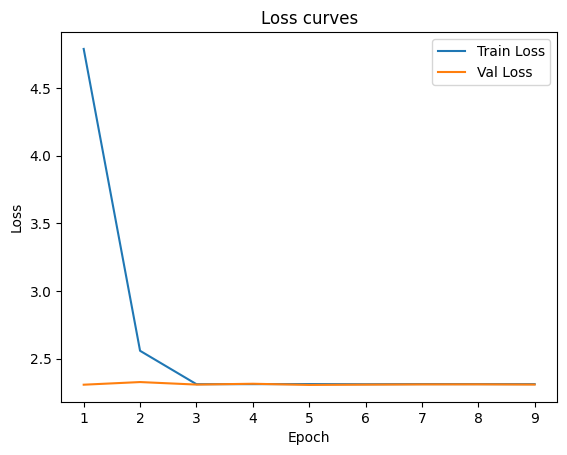

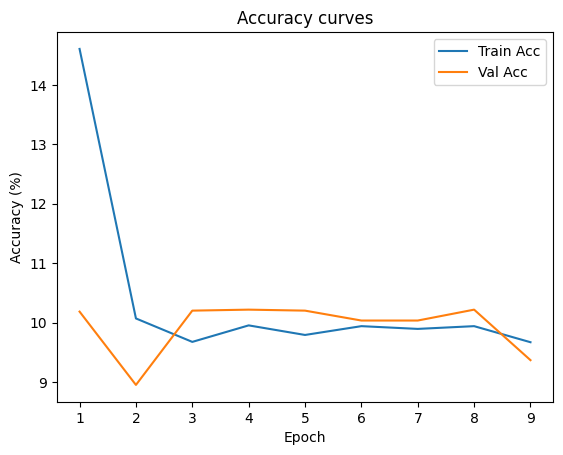

Best Val Acc for LR 0.1: 10.22%

=== LR = 0.01 ===
Epoch 01/30  Train L 0.5653  Val L 0.4797  Train A 79.94%  Val A 83.52%
Epoch 02/30  Train L 0.4512  Val L 0.4549  Train A 84.24%  Val A 84.43%
Epoch 03/30  Train L 0.4137  Val L 0.4153  Train A 85.25%  Val A 85.07%
Epoch 04/30  Train L 0.4088  Val L 0.4509  Train A 85.57%  Val A 84.57%
Epoch 05/30  Train L 0.3995  Val L 0.4411  Train A 85.91%  Val A 85.02%
Epoch 06/30  Train L 0.3904  Val L 0.4758  Train A 86.28%  Val A 84.03%
Epoch 07/30  Train L 0.3822  Val L 0.4468  Train A 86.64%  Val A 85.27%
Epoch 08/30  Train L 0.3837  Val L 0.4417  Train A 86.64%  Val A 85.60%
Epoch 09/30  Train L 0.3686  Val L 0.4951  Train A 87.00%  Val A 85.60%
Epoch 10/30  Train L 0.3627  Val L 0.4963  Train A 87.19%  Val A 83.43%
Epoch 11/30  Train L 0.3572  Val L 0.4422  Train A 87.36%  Val A 85.87%
Epoch 12/30  Train L 0.3568  Val L 0.4710  Train A 87.38%  Val A 85.08%
Epoch 13/30  Train L 0.3565  Val L 0.4171  Train A 87.53%  Val A 86.92%
Epoch 14/30  

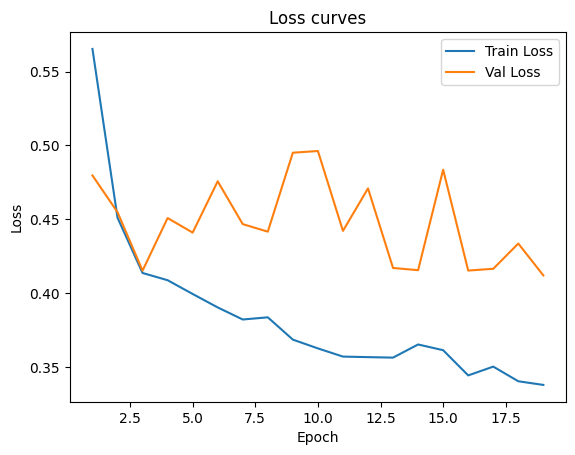

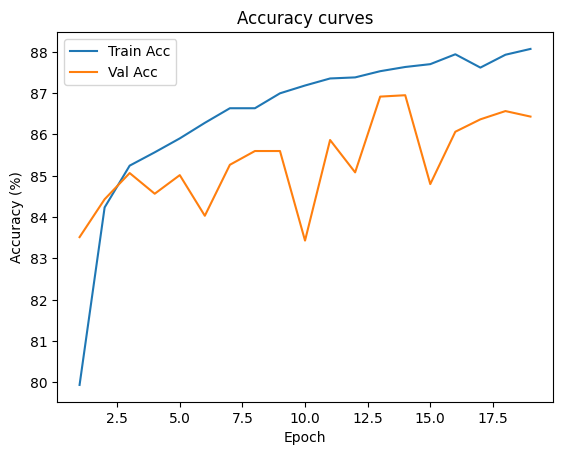

Best Val Acc for LR 0.01: 86.95%

=== LR = 0.001 ===
Epoch 01/30  Train L 0.5018  Val L 0.4078  Train A 81.82%  Val A 85.18%
Epoch 02/30  Train L 0.3755  Val L 0.3637  Train A 86.26%  Val A 86.42%
Epoch 03/30  Train L 0.3335  Val L 0.3444  Train A 87.72%  Val A 87.85%
Epoch 04/30  Train L 0.3130  Val L 0.3572  Train A 88.46%  Val A 87.12%
Epoch 05/30  Train L 0.2902  Val L 0.3300  Train A 89.11%  Val A 88.03%
Epoch 06/30  Train L 0.2723  Val L 0.3326  Train A 89.89%  Val A 87.85%
Epoch 07/30  Train L 0.2581  Val L 0.3283  Train A 90.40%  Val A 88.55%
Epoch 08/30  Train L 0.2452  Val L 0.3191  Train A 90.76%  Val A 88.33%
Epoch 09/30  Train L 0.2311  Val L 0.3173  Train A 91.28%  Val A 88.68%
Epoch 10/30  Train L 0.2207  Val L 0.3381  Train A 91.62%  Val A 88.52%
Epoch 11/30  Train L 0.2128  Val L 0.3628  Train A 91.90%  Val A 88.20%
Epoch 12/30  Train L 0.2017  Val L 0.3114  Train A 92.27%  Val A 89.15%
Epoch 13/30  Train L 0.1937  Val L 0.3277  Train A 92.71%  Val A 89.32%
Epoch 14/30

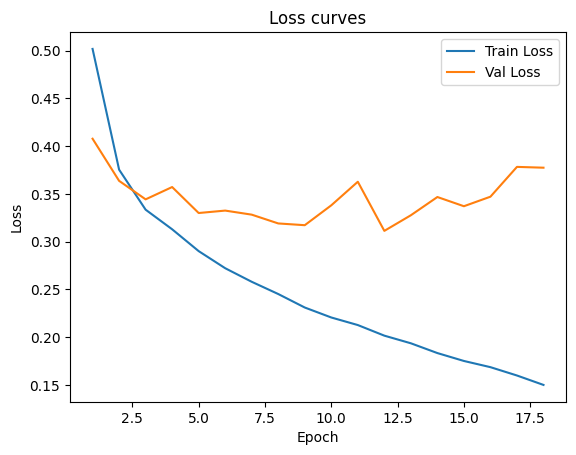

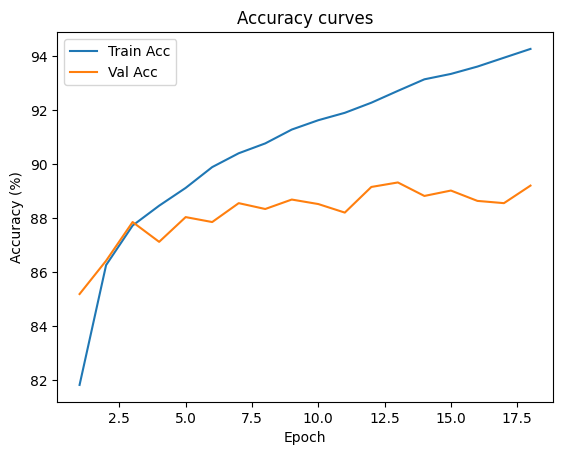

Best Val Acc for LR 0.001: 89.32%


In [10]:
# We reuse the MLP class defined in Step 3.
# Fix hidden sizes during the LR scan to isolate the LR effect.
N1, N2 = 256, 128

def mlp_ctor():
    return MLP(n1=N1, n2=N2, num_classes=10)

# Choose the optimizer family. Adam is a good default for this baseline.
def make_optimizer(lr):
    return lambda params: torch.optim.Adam(params, lr=lr)

lrs_to_try = [0.1, 0.01, 0.001]
results = {}

for lr in lrs_to_try:
    print(f"\n=== LR = {lr} ===")
    log, best_model = train_model(
        model_ctor=mlp_ctor,
        optimizer_ctor=make_optimizer(lr),
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=30,
        patience=5,
        seed=SEED  # same seed for fairness across LRs
    )
    results[lr] = {"log": log, "model": best_model}
    plot_learning_curves(log)
    print(f"Best Val Acc for LR {lr}: {log['best_val_acc']:.2f}%")


### Results: interpreting the LR scan and deciding

We tested three learning rates on the same MLP and with the same batch size.

* **LR = 0.1 → too high**
  - **Evidence**: Train Acc drops toward ~10 percent and Val Acc stays around ~10 percent (random guess).
  - **Curves**: Train Loss falls abruptly then stalls; Val Loss stays flat near ~2.30.
  - **Diagnosis**: step size is too large → the optimizer does not converge (unstable logits / saturation).
  - **Action**: discard 0.1.

* **LR = 0.01 → learning but with oscillations**
  - **Evidence**: Best Val Acc ≈ **86.95 percent** (epochs 13–14), with oscillations after the early phase.
  - **Curves**: Train Loss decreases smoothly; Val Loss goes down then oscillates. Train Acc climbs to ~87–88 percent; Val Acc fluctuates between ~84–87 percent.
  - **Diagnosis**: valid learning but not perfectly stable; signs of **mild overfitting** after ~10–12 epochs (Val Loss bumps while Train Loss still improves).
  - **Action**: acceptable baseline, but not the best.

* **LR = 0.001 → best trade-off**
  - **Evidence**: Best Val Acc ≈ **89.32 percent**, the top result, with clean trends.
  - **Curves**: Train Loss decreases steadily; Val Loss decreases until ~epoch 8–10, then stabilizes or slightly rises. Train Acc reaches ~94 percent; Val Acc stays ~88–89 percent.
  - **Diagnosis**: **stable convergence** and the best generalization among the three; **moderate overfitting** beyond ~12–15 epochs (Train improves while Val plateaus).
  - **Action**: **choose LR = 0.001** for the next MLP steps. Consider a shorter `patience` (3–4), since gains after ~15 epochs are marginal.

**Are 30 epochs enough?**
- Yes, and probably **more than needed** for this MLP. The **validation plateau** appears around **8–15 epochs**. Early stopping already prevents waste.

**Batch size note**
- We kept **batch size fixed** (64) during the LR scan, as required, to isolate the LR effect. Later we can explore 32 and 128.

**Decision**
- **Chosen LR for the MLP**: **0.001** (best Val Acc and most stable curves).
- For future MLP runs: keep LR 0.001, batch size 64, `patience` 3–5.

**Recap**
- **0.1**: too high → non-convergent, ~10 percent Val Acc.
- **0.01**: learns but oscillates, best Val ≈ **86.95 percent**, mild overfitting after ~10–12 epochs.
- **0.001**: **best and stable**, best Val ≈ **89.32 percent**; Val plateaus around ~10–15 epochs.
- **Final choice**: **LR = 0.001** for the MLP with early stopping and fixed batch size.

---


# 💢***Neural Network (CNN)***